# Figure 3 v2: IFFL with Cancer variable

Extends the IFFL model with a Cancer variable `C` whose dynamics depend on
whether the output `y` is above or below its homeostatic steady state.

$$
\frac{dx}{dt} = \alpha\,u - \delta\,x \qquad
\frac{dy}{dt} = \beta\,u - \gamma\,x\,y \qquad
\frac{dC}{dt} = C\bigl(c_1 - c_2\,\max(y_{ss} - y,\,0)\bigr)
$$

- $y_{ss} = \frac{\beta\,\delta}{\gamma\,\alpha}$ (independent of $u$ — RPA)
- Cancer **decays** while $y < y_{ss}$ (output suppressed below steady state)
- Cancer **grows** at baseline rate $c_1$ when $y \geq y_{ss}$


In [220]:
"""Setup: imports, shared parameters, IFFL + Cancer ODE, simulation helpers."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style

set_style()
plt.rcParams['text.usetex'] = False

# ── Plotting helpers ──────────────────────────────────────────────────

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# ── Shared IFFL parameters ────────────────────────────────────────────

PARAMS = dict(alpha=1.0, delta=1.0, beta=1.0, gamma=1.0)

# Cancer kinetics (same convention as rpa_model_class)
C1_CANCER = 0.05   # baseline growth rate
C2_CANCER = 1.0    # kill rate when y is below y_ss

def y_ss_val(p=PARAMS):
    """Analytic steady state of y (independent of u)."""
    return p['beta'] * p['delta'] / (p['gamma'] * p['alpha'])

def steady_state(u, p=PARAMS):
    """Return (x_ss, y_ss) for a given input u."""
    x_ss = p['alpha'] * u / p['delta']
    return x_ss, y_ss_val(p)

# ── IFFL + Cancer ODE ─────────────────────────────────────────────────

Y_SS = y_ss_val()  # fixed at baseline params

def iffl_cancer_rhs(t, state, u, p=PARAMS):
    """
    Right-hand side of the augmented IFFL system.

    state : [x, y, C]
    u     : current input (scalar or callable(t))
    """
    x, y, C = state
    u_val = u(t) if callable(u) else u
    dx = p['alpha'] * u_val - p['delta'] * x
    dy = p['beta']  * u_val - p['gamma'] * x * y
    dC = C * (C1_CANCER - C2_CANCER * max(Y_SS - y, 0.0))
    return [dx, dy, dC]

# ── Simulation helper ─────────────────────────────────────────────────

def simulate(u, t_span, y0=None, n_pts=1000, p=PARAMS):
    """
    Integrate the IFFL+Cancer system.

    u     : constant float or callable(t)
    t_span: (t_start, t_end)
    y0    : [x0, y0, C0]; if None uses SS at constant u with C=1
    """
    if y0 is None:
        u0 = u(t_span[0]) if callable(u) else u
        x0, y0_ss = steady_state(u0, p)
        y0 = [x0, y0_ss, 1.0]   # Cancer starts at 1
    t_eval = np.linspace(*t_span, n_pts)
    sol = solve_ivp(
        lambda t, s: iffl_cancer_rhs(t, s, u, p),
        t_span, y0, t_eval=t_eval,
        method='Radau', rtol=1e-9, atol=1e-11, dense_output=True)
    return sol

print(f"y_ss = {Y_SS:.4f}  (independent of u — RPA confirmed)")
print(f"Cancer: grows at c1={C1_CANCER}, decays at rate c2={C2_CANCER} when y < y_ss")


y_ss = 1.0000  (independent of u — RPA confirmed)
Cancer: grows at c1=0.05, decays at rate c2=1.0 when y < y_ss


/tmp/ipykernel_128885/2653794921.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


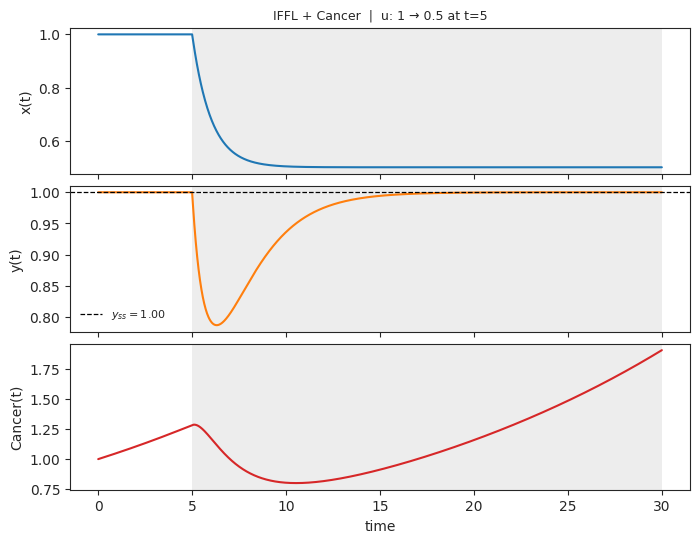

In [221]:
# Quick sanity check: abrupt u switch u=1→2, Cancer starting at 1
T_SWITCH = 5.0
T_END    = 30.0
x0, y0_ss = steady_state(1.0)
y0_init = [x0, y0_ss, 1.0]

u_func = lambda t: 0.5 if t >= T_SWITCH else 1.0

sol = simulate(u_func, (0, T_END), y0=y0_init, n_pts=2000)
t, (xs, ys, Cs) = sol.t, sol.y

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True,
                          gridspec_kw={'hspace': 0.08})

ON_COLOR = 'lightgray'
for ax in axes:
    ax.axvspan(T_SWITCH, T_END, color=ON_COLOR, alpha=0.4, lw=0)


axes[0].plot(t, xs, color='C0', lw=1.5)
axes[0].set_ylabel('x(t)')

axes[1].plot(t, ys, color='C1', lw=1.5)
axes[1].axhline(Y_SS, color='k', ls='--', lw=0.9, label=f'$y_{{ss}}={Y_SS:.2f}$')
axes[1].set_ylabel('y(t)')
axes[1].legend(fontsize=8, frameon=False)

axes[2].plot(t, Cs, color='C3', lw=1.5)
axes[2].set_ylabel('Cancer(t)')
axes[2].set_xlabel('time')

axes[0].set_title('IFFL + Cancer  |  u: 1 → 0.5 at t=5', fontsize=9)
plt.tight_layout()
plt.show()


In [222]:
def sensitization_strategy(params, parameter, baseline_value, prep_value, treat_value,
                            u_base=1.0, ramp_duration=20.0, t_post=30.0,
                            C0=1.0, n_pts=2000):
    """
    Two-stage sensitization + treatment for the IFFL+Cancer model.

    Stage 1 — preparation: linearly ramp `parameter` from baseline_value to
              prep_value over ramp_duration time units.
    Stage 2 — treatment: abruptly switch `parameter` to treat_value and
              integrate for t_post time units.

    A control trajectory is also computed: the baseline ODE runs for the
    full ramp_duration, then the same abrupt treatment is applied.

    Parameters
    ----------
    params         : kinetic parameter dict (e.g. PARAMS); acts as the model
    parameter      : name of the parameter to vary — 'u' or any key in params
    baseline_value : starting value (system begins at its SS here)
    prep_value     : value ramped to during Stage 1
    treat_value    : value applied abruptly in Stage 2
    u_base         : nominal input signal (used when parameter != 'u')
    ramp_duration  : length of Stage 1
    t_post         : length of Stage 2
    C0             : initial Cancer value (default 1.0)
    n_pts          : total number of time points across both stages

    Returns
    -------
    dict with keys:
        t_sens, y_sens   : full sensitized trajectory (3 × n array)
        t_ctrl, y_ctrl   : control trajectory
        param_arr        : parameter value at every sensitized time point
        t_switch         : time of the ramp-to-treatment switch (= ramp_duration)
        y_ss             : homeostatic steady-state of y at baseline params
        parameter, baseline_value, prep_value, treat_value
    """
    # ── helpers ──────────────────────────────────────────────────────
    def resolve(param_val):
        """Return (u_val, p_eff) for the given value of `parameter`."""
        if parameter == 'u':
            return param_val, params
        return u_base, {**params, parameter: param_val}

    def make_rhs(param_val):
        u_val, p_eff = resolve(param_val)
        return lambda t, s: iffl_cancer_rhs(t, s, u_val, p_eff)

    # ── baseline steady state ─────────────────────────────────────────
    u0, p0     = resolve(baseline_value)
    x0, _      = steady_state(u0, p0)
    y_ss_base  = y_ss_val(p0)            # reference for cancer dynamics
    state0     = [x0, y_ss_base, C0]

    n_ramp = max(int(n_pts * ramp_duration / (ramp_duration + t_post)), 100)
    n_post = max(n_pts - n_ramp, 100)

    # ── Stage 1: ramp (sensitized) ────────────────────────────────────
    def ramp_val(t):
        frac = min(t / ramp_duration, 1.0)
        return baseline_value + (prep_value - baseline_value) * frac

    def rhs_ramp(t, s):
        u_val, p_eff = resolve(ramp_val(t))
        return iffl_cancer_rhs(t, s, u_val, p_eff)

    t_ramp_arr = np.linspace(0, ramp_duration, n_ramp)
    sol_ramp   = solve_ivp(rhs_ramp, (0, ramp_duration), state0,
                            t_eval=t_ramp_arr, method='Radau', rtol=1e-9, atol=1e-11)

    # ── Stage 2: treatment (sensitized) ──────────────────────────────
    # FIX: Integrate from ramp_duration to match the control trajectory timeframe
    t_post_arr = np.linspace(ramp_duration, ramp_duration + t_post, n_post)
    sol_treat  = solve_ivp(make_rhs(treat_value), (ramp_duration, ramp_duration + t_post), sol_ramp.y[:, -1],
                            t_eval=t_post_arr, method='Radau', rtol=1e-9, atol=1e-11)

    # ── Control: baseline ODE during ramp, then treatment ───────────
    sol_ctrl_ramp  = solve_ivp(make_rhs(baseline_value), (0, ramp_duration), state0,
                                t_eval=t_ramp_arr, method='Radau', rtol=1e-9, atol=1e-11)

    t_ctrl_post    = np.linspace(ramp_duration, ramp_duration + t_post, n_post)
    sol_ctrl_treat = solve_ivp(make_rhs(treat_value),
                                (ramp_duration, ramp_duration + t_post),
                                sol_ctrl_ramp.y[:, -1],
                                t_eval=t_ctrl_post, method='Radau', rtol=1e-9, atol=1e-11)

    t_ctrl = np.concatenate([sol_ctrl_ramp.t, sol_ctrl_treat.t[1:]])
    y_ctrl = np.concatenate([sol_ctrl_ramp.y, sol_ctrl_treat.y[:, 1:]], axis=1)

    # ── Combine sensitized trajectory ─────────────────────────────────
    # FIX: No longer artificially shifting sol_treat.t since we fixed the integration timeframe
    t_sens    = np.concatenate([sol_ramp.t, sol_treat.t[1:]])
    y_sens    = np.concatenate([sol_ramp.y, sol_treat.y[:, 1:]], axis=1)
    
    param_arr = np.concatenate([
        np.array([ramp_val(t) for t in sol_ramp.t]),
        np.full(len(sol_treat.t) - 1, treat_value),
    ])

    return dict(
        t_sens=t_sens, y_sens=y_sens,
        t_ctrl=t_ctrl, y_ctrl=y_ctrl,
        param_arr=param_arr,
        t_switch=ramp_duration,
        y_ss=y_ss_base,
        parameter=parameter,
        baseline_value=baseline_value,
        prep_value=prep_value,
        treat_value=treat_value,
    )

In [223]:
def plot_sensitization(res):
    """Plot y(t), Cancer(t), and parameter(t) for a sensitization result."""

    TREAT_COLOR = 'lightgray'

    t_sw   = res['t_switch']
    t_end  = res['t_sens'][-1]

    fig, (ax_y, ax_C, ax_p) = plt.subplots(
        3, 1, figsize=(9, 7), sharex=True,
        gridspec_kw={'height_ratios': [2, 2, 1], 'hspace': 0.08})

    for ax in (ax_y, ax_C, ax_p):
        ax.axvspan(t_sw, t_end, color=TREAT_COLOR, alpha=0.4, lw=0)
        ax.axvline(t_sw, color='k', ls=':', lw=0.9, alpha=0.6)
        clean_ax(ax)

    # ── y(t) ─────────────────────────────────────────────────────────
    ax_y.plot(res['t_sens'], res['y_sens'][1], color='steelblue', lw=1.8, label='sensitized')
    ax_y.plot(res['t_ctrl'], res['y_ctrl'][1], color='tomato',    lw=1.8, ls='--', label='control')
    ax_y.axhline(res['y_ss'], color='k', ls='--', lw=1,
                 label=f"$y_{{ss}} = {res['y_ss']:.2f}$")
    ax_y.set_ylabel('y(t)')
    ax_y.legend(handles=[
        plt.Line2D([0],[0], color='steelblue', lw=1.8, label='sensitized'),
        plt.Line2D([0],[0], color='tomato',    lw=1.8, ls='--', label='control'),
        plt.Line2D([0],[0], color='k',         lw=1,   ls='--',
                   label=f"$y_{{ss}}={res['y_ss']:.2f}$"),
        mpatches.Patch(facecolor=TREAT_COLOR, alpha=0.6,
                       label=f"treat → {res['treat_value']:.3g}"),
    ], fontsize=8, frameon=False)

    # ── Cancer(t) ─────────────────────────────────────────────────────
    c_s = res['y_sens'][2]
    c_c = res['y_ctrl'][2]

    ax_C.plot(res['t_sens'], c_s, color='steelblue', lw=1.8)
    ax_C.plot(res['t_ctrl'], c_c, color='tomato',    lw=1.8, ls='--')
    ax_C.set_ylabel('Cancer(t)')

    t_sw      = res['t_switch']
    n_treat   = np.searchsorted(res['t_sens'], t_sw, side='right')
    stats = ('sensitized:  min=%.3f  final=%.3f\n'
             'control:     min=%.3f  final=%.3f') % (
             c_s[n_treat:].min(), c_s[-1], c_c[n_treat:].min(), c_c[-1])
    ax_C.text(0.02, 0.97, stats, transform=ax_C.transAxes,
              fontsize=7.5, ha='left', va='top', family='monospace',
              bbox=dict(facecolor='white', alpha=0.75, edgecolor='none',
                        boxstyle='round,pad=0.3'))

    # ── parameter(t) ──────────────────────────────────────────────────
    p_ctrl = np.where(res['t_ctrl'] <= t_sw,
                      res['baseline_value'], res['treat_value'])
    ax_p.plot(res['t_sens'], res['param_arr'],  color='steelblue', lw=1.5)
    ax_p.plot(res['t_ctrl'], p_ctrl,            color='tomato',    lw=1.5, ls='--')
    ax_p.set_ylabel(res['parameter'])
    ax_p.set_xlabel('time')
    yticks = sorted({res['baseline_value'], res['prep_value'], res['treat_value']})
    ax_p.set_yticks(yticks)
    ax_p.set_yticklabels([f"{v:.3g}" for v in yticks], fontsize=7)

    fig.suptitle(
        f"Sensitization — {res['parameter']}: "
        f"{res['baseline_value']:.3g} → {res['prep_value']:.3g} → {res['treat_value']:.3g}",
        fontsize=10)
    plt.tight_layout()
    return fig


/tmp/ipykernel_128885/1619520524.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


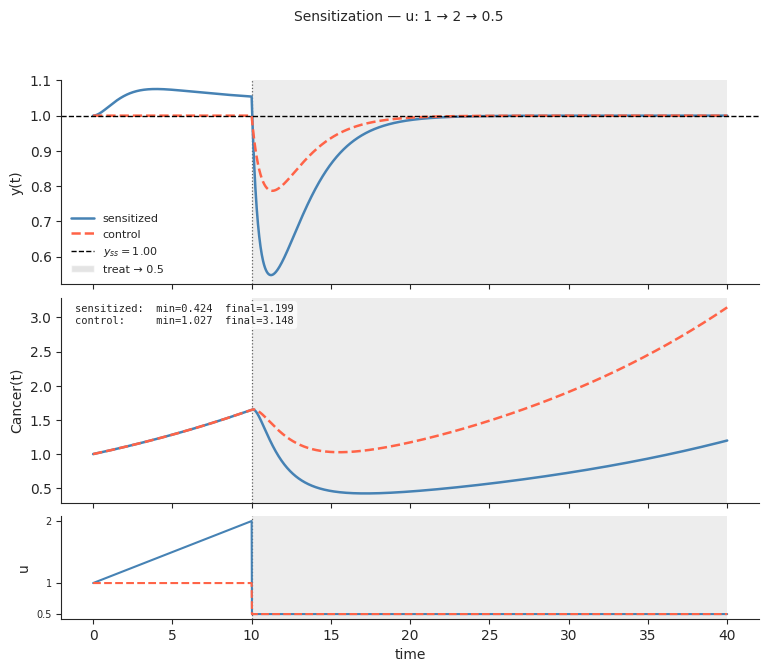

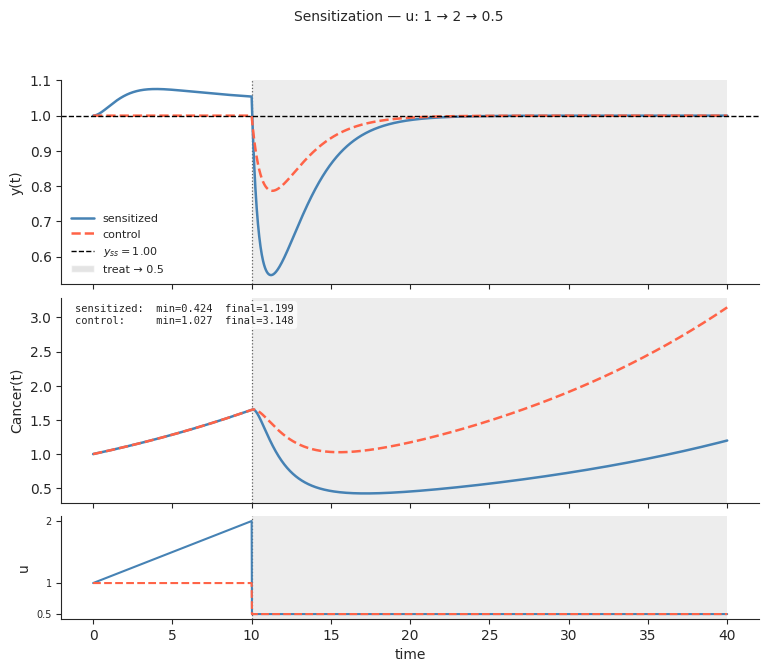

In [228]:
# Example
res = sensitization_strategy(
    PARAMS,
    parameter='u',
    baseline_value=1.0,
    prep_value=2.0,
    treat_value=0.5,
    ramp_duration=10.0,
    t_post=30.0,
)
plot_sensitization(res)


In [225]:
def run_heatmap_scan(params, parameter, baseline_value, treat_value,
                     prep_values, ramp_durations,
                     t_post=15.0, C0=1.0, n_pts=600):
    """
    Scan a 2-D grid of (ramp_duration × prep_value) and record
    final Cancer / C0 at the end of each sensitization run.

    Reference: start treatment immediately (no ramp) for t_post time.
    Grid cells below the reference value benefited from sensitization.

    Parameters
    ----------
    params         : kinetic parameter dict
    parameter      : 'u' or any key in params
    baseline_value : starting value of the parameter
    treat_value    : treatment value (Stage 2)
    prep_values    : 1-D array of prep_value candidates (Stage 1 target)
    ramp_durations : 1-D array of ramp duration candidates
    t_post         : fixed treatment duration (same for all grid points)
    C0             : initial Cancer value

    Returns
    -------
    dict with grid, cancer_ref, axes, and metadata
    """
    def resolve(pv):
        if parameter == 'u':
            return pv, params
        return 1.0, {**params, parameter: pv}

    # ── Reference: treat immediately for t_post ───────────────────────
    u0, p0        = resolve(baseline_value)
    x0, y0_ss     = steady_state(u0, p0)
    u_treat, p_tr = resolve(treat_value)

    sol_ref    = solve_ivp(
        lambda t, s: iffl_cancer_rhs(t, s, u_treat, p_tr),
        (0, t_post), [x0, y0_ss, C0],
        method='Radau', rtol=1e-9, atol=1e-11, t_eval=[0, t_post])
    cancer_ref = sol_ref.y[2, -1] / C0

    # ── Grid scan ─────────────────────────────────────────────────────
    n_rd   = len(ramp_durations)
    n_pv   = len(prep_values)
    grid   = np.zeros((n_rd, n_pv))
    n_done = 0

    for i, rd in enumerate(ramp_durations):
        for j, pv in enumerate(prep_values):
            res = sensitization_strategy(
                params, parameter, baseline_value, pv, treat_value,
                ramp_duration=rd, t_post=t_post, C0=C0, n_pts=n_pts)
            grid[i, j] = res['y_sens'][2, -1] / C0
            n_done += 1
        print(f"  {n_done}/{n_rd * n_pv} done", end='\r')
    print(f"  {n_rd * n_pv}/{n_rd * n_pv} done — reference = {cancer_ref:.4f}")

    return dict(
        grid=grid, cancer_ref=cancer_ref,
        prep_values=np.asarray(prep_values),
        ramp_durations=np.asarray(ramp_durations),
        parameter=parameter, t_post=t_post,
        baseline_value=baseline_value, treat_value=treat_value, C0=C0,
    )


In [226]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap  # Added for custom colors

def plot_heatmap(scan):
    """
    Heatmap of (Cancer(end)/C0) - reference, centred at 0.
    Green = sensitization reduces final tumour below immediate-treatment baseline.
    Red   = sensitization increases final tumour above baseline.
    White = break-even point (0).
    Star marks the grid point with the greatest improvement.
    """
    grid  = scan['grid']
    pv    = scan['prep_values']
    rd    = scan['ramp_durations']
    ref   = scan['cancer_ref']

    delta = grid - ref          # negative = better than reference

    max_abs = np.abs(delta).max() or 1e-6
    best_i, best_j = np.unravel_index(np.argmin(delta), delta.shape)

    fig, ax = plt.subplots(figsize=(8, 6))

    # --- NEW COLORMAP LOGIC ---
    # Creates a strict Green -> White -> Red gradient
    # Since vmin and vmax are symmetric (-max_abs to max_abs), White will perfectly align with 0
    gwr_cmap = LinearSegmentedColormap.from_list(
        'GreenWhiteRed', ['forestgreen', 'white', 'firebrick']
    )

    im = ax.pcolormesh(pv, rd, delta, cmap=gwr_cmap, shading='auto',
                       vmin=-max_abs, vmax=max_abs)
    
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('Cancer(end)/C0  −  reference', fontsize=9)
    cb.ax.axhline(0, color='k', lw=1.2)

    ax.contour(pv, rd, delta, levels=[0],
               colors='k', linewidths=1.5, linestyles='--')

    ax.scatter(pv[best_j], rd[best_i], marker='*', s=220, color='navy', zorder=5,
               label=(f"best: prep={pv[best_j]:.2f}, ramp={rd[best_i]:.1f}\n"
                      f"Δ Cancer = {delta[best_i, best_j]:+.3f}"))

    ax.set_xlabel(f"{scan['parameter']} during ramp  (prep_value)", fontsize=9)
    ax.set_ylabel('ramp_duration', fontsize=9)
    
    ax.set_title(
        f"Sensitization benefit  |  {scan['parameter']}: "
        f"{scan['baseline_value']:.2g} → prep → {scan['treat_value']:.2g}  |  "
        f"t_post = {scan['t_post']}\n"
        f"Colour = final Cancer − reference ({ref:.3f}).  Black line = break-even.",
        fontsize=9)
        
    ax.legend(fontsize=8, frameon=False, loc='upper left')
    clean_ax(ax) 
    
    plt.tight_layout()
    return fig

  100/100 done — reference = 1.9091


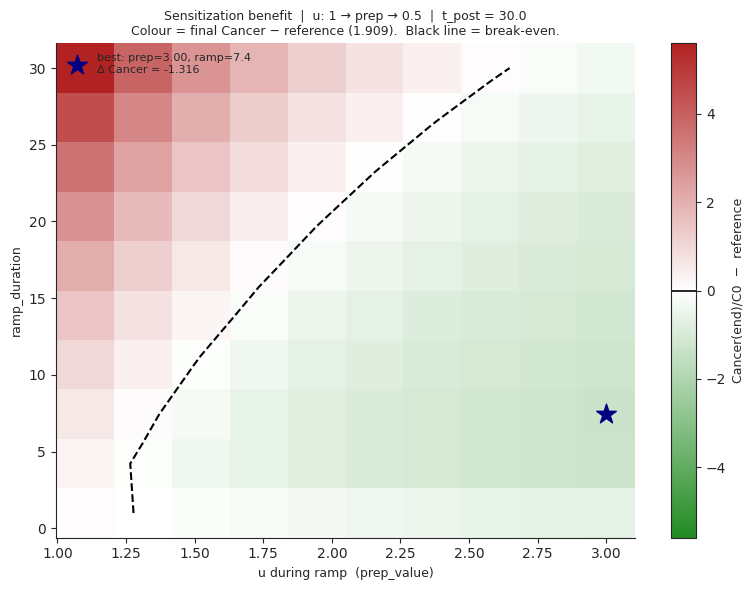

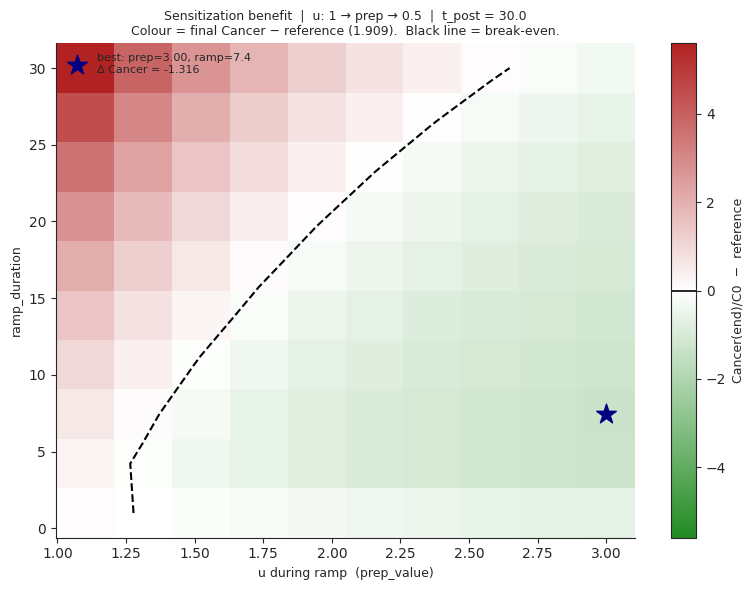

In [227]:
PREP_VALUES    = np.linspace(1.1, 3.0, 10)   # u values during ramp (above baseline=1)
RAMP_DURATIONS = np.linspace(1, 30, 10)       # ramp durations to explore

scan = run_heatmap_scan(
    PARAMS,
    parameter='u',
    baseline_value=1.0,
    treat_value=0.5,
    prep_values=PREP_VALUES,
    ramp_durations=RAMP_DURATIONS,
    t_post=30.0,
)
plot_heatmap(scan)
